## Determining the phase shifts for scattering in a Lennard-Jones potential

In [28]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt
import scipy.constants as const

In [29]:
m_H  = 1.008 * const.u          # kg
m_Kr = 83.798 * const.u         # kg
mu   = m_H * m_Kr / (m_H + m_Kr)  # kg

hbar2_over_2mu = const.hbar**2 / (2 * mu)  # J·m²
hbar2_over_2mu_meV_A2 = hbar2_over_2mu * 6.242e21 * 1e20
print(f"ℏ²/2µ = {hbar2_over_2mu_meV_A2:.6f} meV·Å²")

ℏ²/2µ = 2.098599 meV·Å²


In [139]:
kwargs = {'hbar_squared_over_2_m' : 2.098599, 'sigma' : 3.101951703070589, 'epsilon' : 5.99}
cmap = plt.get_cmap('tab20')

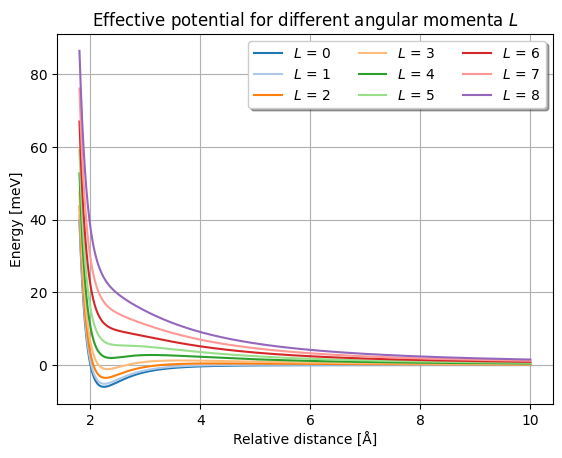

In [31]:
# print the effective potential for different angular momenta
r = np.linspace(0.9 * kwargs['sigma'], 10, 1000)
ls = np.arange(0, 9, 1)

plt.title('Effective potential for different angular momenta $L$')
i = 0
for _l in ls:
    color = cmap(i)
    plt.plot(r, phys.effective_potential(r, _l, phys.lennard_jones, **kwargs), color = color, label = f'$L$ = {_l}')
    i += 1

plt.xlabel('Relative distance [Å]')
plt.ylabel('Energy [meV]')
plt.legend(ncols = 3, fancybox = True, shadow = True)
plt.grid()
plt.savefig('imgs/LJ.pdf', bbox_inches='tight')
plt.show()


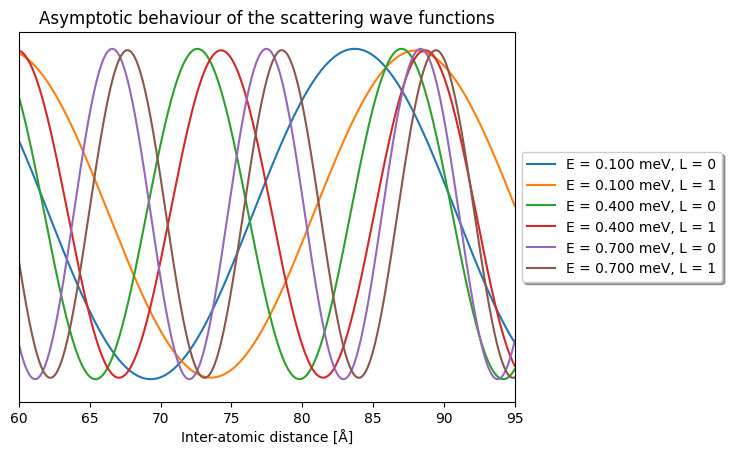

In [32]:
# print a few oscillations in the asymptotic regime
h = 1e-3
r_max = 100
E = np.arange(0.1, 1, .3)
ls = np.arange(0, 2, 1)

grid = phys.potentials.helper_grid_lj(h, r_max, sigma = kwargs['sigma'])
solver = phys.numerics.SolverOpts()

plt.title('Asymptotic behaviour of the scattering wave functions')
i = 0
for _E in E:
    for _l in ls:
        coord, psi = phys.scattering.integrate_scattering_state(_E, _l, phys.potentials.lennard_jones, grid = grid, solver = solver, **kwargs)
        color = cmap(i)
        plt.plot(coord, psi/np.max(psi), label = f'E = {_E:.3f} meV, L = {_l}')
        i += 1

plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.yticks(ticks = [])
plt.xlim([60, 95])
plt.xlabel('Inter-atomic distance [Å]')
plt.show()


Solve the Schrodinger equation for $l \in [0, 6]$ and $E \in [0.1, 3.5)$

In [140]:
ls = np.arange(0, 9, 1)
E = np.arange(0.01, 3.5, 0.01)
hs = [1e-3]
solver = phys.numerics.SolverOpts()

In [ ]:
i = 0
phases = np.zeros((len(hs), len(E), len(ls)))

for _h in hs:
    j = 0
    for _E in E:
        z = 0
        for _l in ls:
            points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], _h,)
            r_min = phys.r_asym_min(_E, _l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
            r_max = r_min + points_needed * _h
            grid = phys.potentials.helper_grid_lj(_h, r_max, sigma = kwargs['sigma'])
            print(f'For E = {_E:.3f} and sigma = {kwargs['sigma']} and l = {_l} h = {_h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
            coord, psi = phys.integrate_scattering_state(_E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
            # compute phases
            mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, _l, **kwargs)
            print(f'For E = {_E:.3f} and sigma = {kwargs['sigma']} and l = {_l} h = {_h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
            phases[i, j, z] = mean_phase
            z += 1
        j += 1
    i += 1
    

In [142]:
phases_unwrap_l_8 = np.unwrap(phases, period=np.pi, axis = 1)

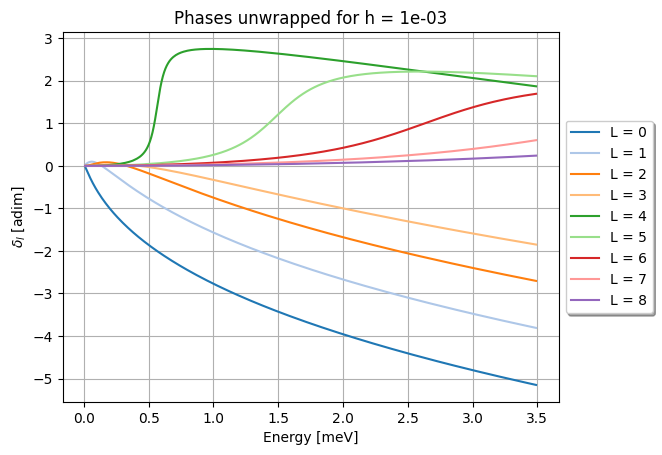

In [148]:
k = 0
l = 0
colors = [cmap(i) for i in range(cmap.N)]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

for h in hs:
    for _l in ls:
        plt.title(f'Phases unwrapped for h = {h:.0e}')
        plt.xlabel('Energy [meV]')
        plt.ylabel(r'$\delta_l$ [adim]')
        plt.plot(E, phases_unwrap_l_8[k, :, l], label = f'L = {_l}')
        l += 1
    k += 1
    l = 0
    
plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.grid()
plt.savefig('imgs/phases_good_sigma.pdf', bbox_inches='tight')
plt.show()

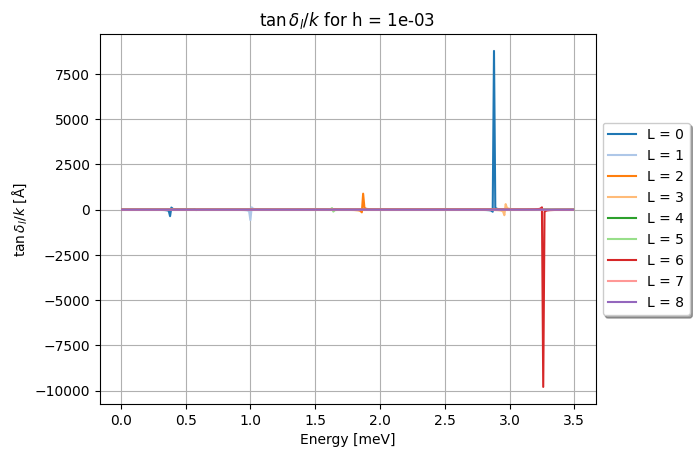

In [147]:
k = 0
l = 0
colors = [cmap(i) for i in range(cmap.N)]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

for h in hs:
    for _l in ls:
        plt.xlabel('Energy [meV]')
        plt.ylabel(r'$\tan{\delta_l} / k$ [Å]')
        plt.title(r'$\tan{\delta_l} / k$' + f' for h = {h:.0e}')
        plt.plot(E, (np.tan(phases_unwrap_l_8[k, :, l]) / phys.wave_vector(E, **kwargs)), label = f'L = {_l}')
        l += 1
    k += 1
    l = 0

plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.grid()
plt.savefig('imgs/scattering_good_sigma_length.pdf', bbox_inches='tight')
plt.show()

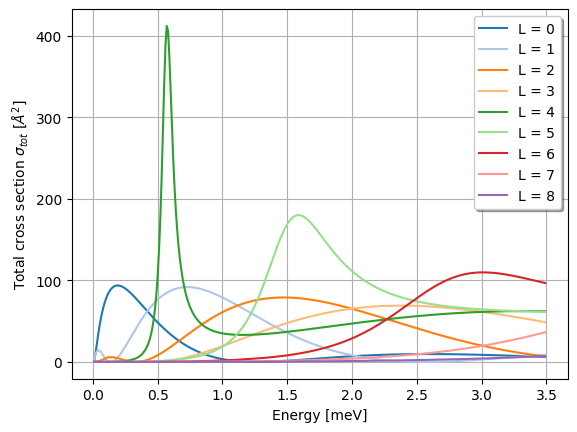

In [166]:
i = 0

for h in hs:
    j = 0
    for _l in ls:
        cross_sections = 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases_unwrap_l_8[i, :, j]), 2) / E
        plt.plot(E, cross_sections, label = f'L = {_l}')
        plt.ylabel(r'Total cross section $\sigma_{tot}$ [$Å^2$]')
        plt.xlabel('Energy [meV]')
        plt.legend(fancybox = True, shadow = True)
        j += 1
    i += 1

plt.grid()
plt.savefig('imgs/cross_section_good_sigma_different_l.pdf', bbox_inches='tight')

In [150]:
cross_sections_l_8 = np.zeros((len(hs), len(E)))
i = 0

for h in hs:
    j = 0
    for _l in ls:
        cross_sections_l_8[i] += 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases_unwrap_l_8[i, :, j]), 2) / E
        j += 1
    i += 1

In [156]:
ls = np.arange(0, 7, 1)
E = np.arange(0.01, 3.5, 0.01)
hs = [1e-3]
solver = phys.numerics.SolverOpts()

In [ ]:
i = 0
phases = np.zeros((len(hs), len(E), len(ls)))

for _h in hs:
    j = 0
    for _E in E:
        z = 0
        for _l in ls:
            points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], _h,)
            r_min = phys.r_asym_min(_E, _l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
            r_max = r_min + points_needed * _h
            grid = phys.potentials.helper_grid_lj(_h, r_max, sigma = kwargs['sigma'])
            print(f'For E = {_E:.3f} and sigma = {kwargs['sigma']} and l = {_l} h = {_h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
            coord, psi = phys.integrate_scattering_state(_E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
            # compute phases
            mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, _l, **kwargs)
            print(f'For E = {_E:.3f} and sigma = {kwargs['sigma']} and l = {_l} h = {_h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
            phases[i, j, z] = mean_phase
            z += 1
        j += 1
    i += 1
    

In [158]:
phases_unwrap_l_6 = np.unwrap(phases, period=np.pi, axis = 1)

In [159]:
cross_sections_l_6 = np.zeros((len(hs), len(E)))
i = 0

for h in hs:
    j = 0
    for _l in ls:
        cross_sections_l_6[i] += 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases_unwrap_l_6[i, :, j]), 2) / E
        j += 1
    i += 1

For h = 1.0e-03 and l = 8 found peak at 0.570.
For h = 1.0e-03 and l = 8 found peak at 1.600.
For h = 1.0e-03 and l = 8 found peak at 2.890.
For h = 1.0e-03 and l = 6 found peak at 0.570.
For h = 1.0e-03 and l = 6 found peak at 1.590.
For h = 1.0e-03 and l = 6 found peak at 2.770.


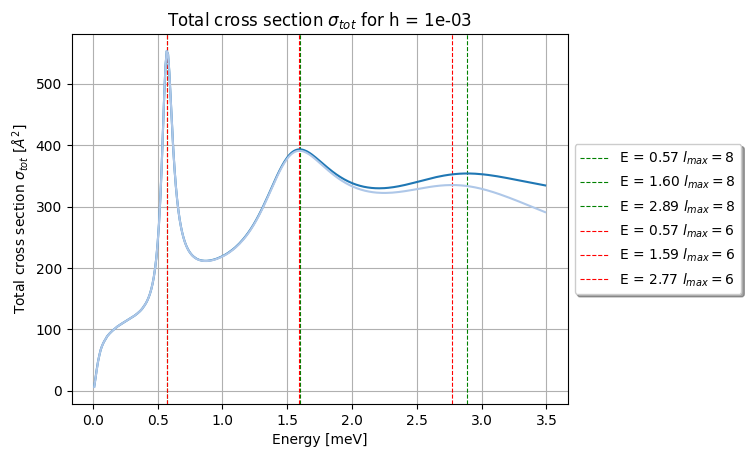

In [168]:
from scipy.signal import find_peaks
i = 0

for h in hs:
    plt.title(r'Total cross section $\sigma_{tot}$ for ' + f'h = {h:.0e}')
    peaks, _ = find_peaks(cross_sections_l_8[i])
    for peak in peaks:
        print(f'For h = {h:.1e} and l = 8 found peak at {E[peak]:.3f}.')
        plt.axvline(E[peak], ymin=0, ymax=1, color='g', linestyle = 'dashed', linewidth=0.8, label = f'E = {E[peak]:.2f} ' + r'$l_{max} = 8$')
    peaks, _ = find_peaks(cross_sections_l_6[i])
    for peak in peaks:
        print(f'For h = {h:.1e} and l = 6 found peak at {E[peak]:.3f}.')
        plt.axvline(E[peak], ymin=0, ymax=1, color='r', linestyle = 'dashed', linewidth=0.8, label = f'E = {E[peak]:.2f} ' + r'$l_{max} = 6$')
    plt.ylabel(r'Total cross section $\sigma_{tot}$ [$Å^2$]')
    plt.xlabel('Energy [meV]')
    plt.plot(E, cross_sections_l_8[i])
    plt.plot(E, cross_sections_l_6[i])
    plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
    i += 1

plt.grid()
plt.savefig('imgs/cross_section_different_ls.pdf', bbox_inches='tight')
plt.show()

For h = 1.0e-03 found peak at 0.090.
For h = 1.0e-03 found peak at 0.600.


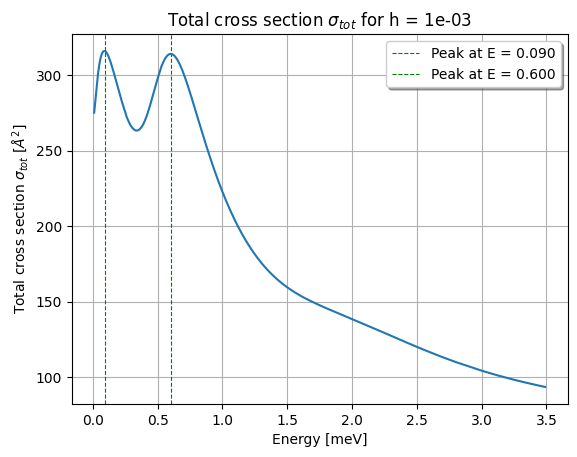

In [83]:
from scipy.signal import find_peaks
i = 0

for h in hs:
    plt.title(r'Total cross section $\sigma_{tot}$ for ' + f'h = {h:.0e}')
    peaks, _ = find_peaks(cross_sections_l_8[i])
    for peak in peaks:
        print(f'For h = {h:.1e} found peak at {E[peak]:.3f}.')
        plt.axvline(E[peak], ymin=0, ymax=1, color='g', linestyle = 'dashed', linewidth=0.8, label = f'Peak at E = {E[peak]:.3f}')
    plt.ylabel(r'Total cross section $\sigma_{tot}$ [$Å^2$]')
    plt.xlabel('Energy [meV]')
    plt.plot(E, cross_sections_l_8[i])
    plt.legend(fancybox = True, shadow = True)
    i += 1

plt.grid()
plt.savefig('imgs/cross_section.pdf', bbox_inches='tight')
plt.show()

In [85]:
from scipy import signal
from scipy.optimize import curve_fit

solver = phys.numerics.SolverOpts()

def parabola(x, a = 1, b = 1, c = 1):
    return a * x**2 + b * x + c

def single_energy_error(sigma_variable, l = [], E_exp = [], _h = 1e-2):
    sigma = float(np.atleast_1d(sigma_variable)[0])
    kwargs = {'hbar_squared_over_2_m' : 2.098599, 'sigma' : sigma, 'epsilon' : 5.99}
    print(f'I got sigma = {sigma_variable} l = {l} E_exp = {E_exp} h = {_h}')
    E = np.arange(0.1, 3.1, 0.01)
    phases = np.zeros((len(E), len(l)))
    j = 0
    for _E in E:
        z = 0
        for _l in l:
            points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], _h)
            r_min = phys.r_asym_min(_E, _l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
            r_max = r_min + points_needed * _h
            grid = phys.potentials.helper_grid_lj(_h, r_max, sigma = kwargs['sigma'])
            #print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
            coord, psi = phys.integrate_scattering_state(_E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
            # compute phases
            mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, _l, **kwargs)
            #print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
            phases[j, z] = mean_phase
            z += 1
        j += 1

    cross_section=np.zeros(len(E))
    i = 0
    for _l in l:
        cross_section += 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases[:, i]), 2) / E
        i += 1

    peak_index, _ = signal.find_peaks(cross_section)
    E_peaks = []
    for peak in peak_index:
        x_fit = E[peak-5:peak+4]
        y_fit = cross_section[peak-5:peak+4]
        params = curve_fit(parabola, x_fit, y_fit)
        a = params[0][0]
        b = params[0][1]
        maximum = -b / (2 * a)
        E_peaks.append(maximum)

    E_peaks = np.array(E_peaks)
    if len(E_peaks) != 3:
        return None
    
    print(f'Peaks at {E_peaks}')
    error = np.sum(np.pow(E_peaks - E_exp, 2))
    print(f'For sigma = {sigma} we got error = {error}')

    return error

In [ ]:
sigmas = np.arange(3., 3.2, 0.005)
ls = np.arange(0, 9, 1)
errors = []

for sigma in sigmas:
    errors.append(single_energy_error(sigma, l = ls, E_exp = [0.5, 1.59, 2.94], _h = 1e-3))

In [97]:
errors = np.array(errors)
is_none = np.where(errors == None, False, True)

In [101]:
sigmas = sigmas[is_none]
errors = errors[is_none]

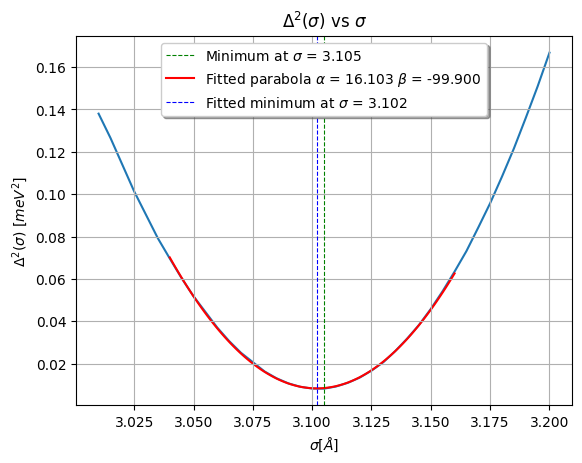

In [ ]:
plt.title(r'$\Delta^2(\sigma)$ vs $\sigma$')
peaks, _ = find_peaks(-errors)
plt.plot(sigmas, errors, zorder = 0)
for peak in peaks:
    plt.axvline(sigmas[peak], ymin=0, ymax=1, color='g', linestyle = 'dashed', linewidth=0.8, label = r'Minimum at $\sigma$ = {:.3f}'.format(sigmas[peak]))
    params = curve_fit(parabola, sigmas[peak-11:peak+10], errors[peak-11:peak+10])
    a = params[0][0]
    b = params[0][1]
    c = params[0][2]
    x = np.linspace(sigmas[peak-11], sigmas[peak+11], 100)
    plt.plot(x, a * x**2 + b * x + c, c = 'r', zorder = 1, label = r'Fitted parabola $\alpha$ = {:.3f} $\beta$ = {:.3f}'.format(a, b))
    plt.axvline(-b / (2*a), ymin=0, ymax=1, color='b', linestyle = 'dashed', linewidth=0.8, label = r'Fitted minimum at $\sigma$ = {:.3f}'.format(-b / (2*a)))
plt.xlabel(r'$\sigma [Å]$')
plt.ylabel(r'$\Delta^2(\sigma)$ [$meV^2$]')
plt.legend(loc = 'upper center', fancybox = True, shadow = True)
plt.grid()
plt.savefig('imgs/delta_squared.pdf', bbox_inches='tight')
plt.show()

In [ ]:
overall_error = 0.1 * np.sqrt(1/(a))

In [124]:
overall_error

np.float64(0.017621155052827017)

In [138]:
-b / (2*a)

np.float64(3.101951703070589)